Roll Number: 27

Name: Aatif Shaikh

Date of Performance: 5 Januaray 2026

Problem Statement:  Real estate agents want help to predict the house price for regions in the USA.
He gave you the dataset to work on and you decided to use the Linear Regression Model. Create a
model that will help him to estimate what the house would sell for.
URL for a dataset:
https://github.com/huzaifsayed/Linear-Regression-Model-for-House-Price-Prediction/blob/master/USA_Housing.csv


In [1]:
# CELL 1: Import all required libraries
import numpy as np              # For numerical operations (arrays, math)
import pandas as pd             # For data manipulation (DataFrames, CSV reading)
import matplotlib.pyplot as plt # For creating plots and charts
import seaborn as sns           # For beautiful statistical visualizations (built on matplotlib)

from sklearn.model_selection import train_test_split   # Splits data into train & test sets
from sklearn.linear_model import LinearRegression      # The Linear Regression algorithm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics

import warnings
warnings.filterwarnings('ignore')  # Hide unnecessary warning messages

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# CELL 2: Load the dataset
df = pd.read_csv('USA_Housing.csv')  # Read the uploaded file

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
# .shape returns (rows, columns) → (5000, 7)
print(f"  → {df.shape[0]} rows (houses/samples)")
print(f"  → {df.shape[1]} columns (features + target + address)")

Dataset loaded successfully!
Shape: (5000, 7)
  → 5000 rows (houses/samples)
  → 7 columns (features + target + address)


In [3]:
# CELL 3: View the first 5 rows of the dataset
df.head()


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
# CELL 4: Check data types, non-null counts, and missing values
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB

=== Missing Values ===
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [5]:
# CELL 5: Descriptive statistics of all numeric columns
df.describe()


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [6]:
# CELL 6: Correlation analysis — how strongly each feature relates to Price
numeric_df = df.select_dtypes(include=[np.number])

correlation_matrix = numeric_df.corr()

print("Correlation of each feature with Price:")
print(correlation_matrix['Price'].sort_values(ascending=False))


Correlation of each feature with Price:
Price                           1.000000
Avg. Area Income                0.639734
Avg. Area House Age             0.452543
Area Population                 0.408556
Avg. Area Number of Rooms       0.335664
Avg. Area Number of Bedrooms    0.171071
Name: Price, dtype: float64


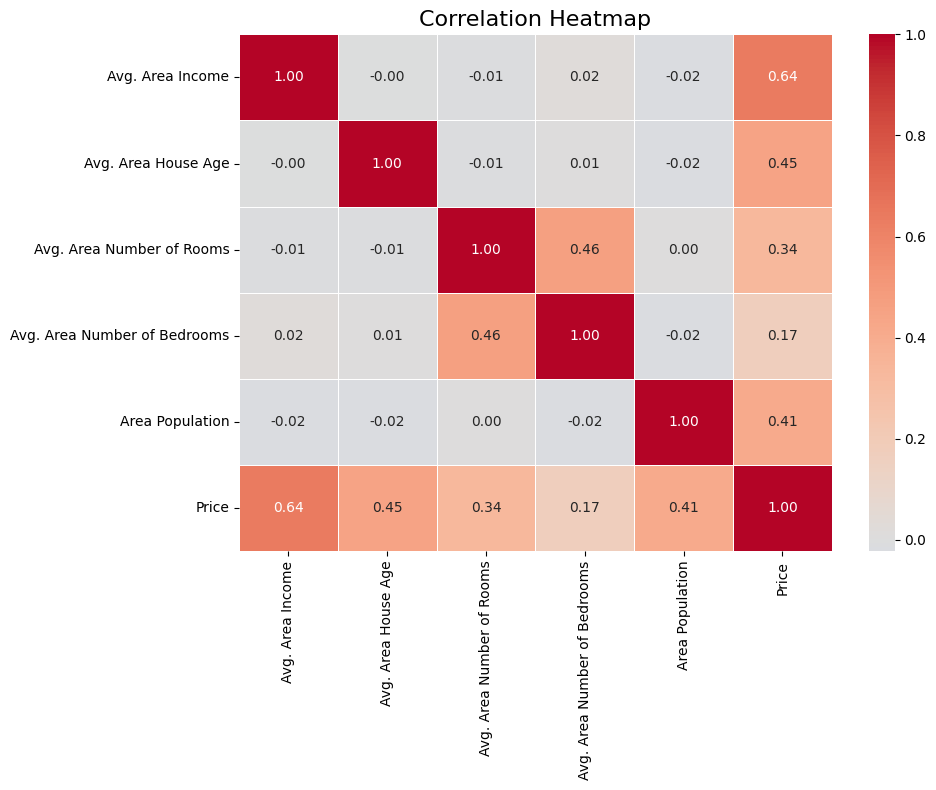

In [7]:
# CELL 7: Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()  # Adjusts spacing so nothing gets cut off
plt.show()

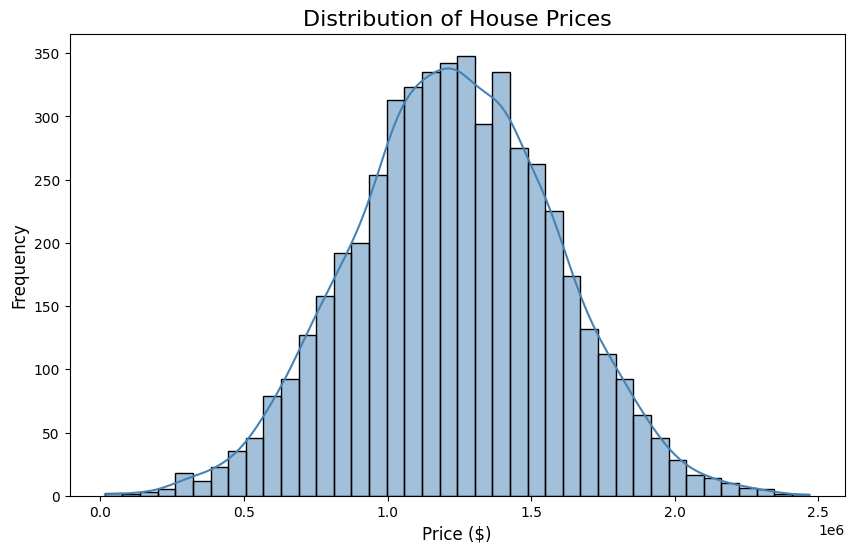

In [8]:
# CELL 8: Distribution of the target variable (Price)
plt.figure(figsize=(10, 6))

sns.histplot(df['Price'], kde=True, bins=40, color='steelblue')
plt.title('Distribution of House Prices', fontsize=16)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

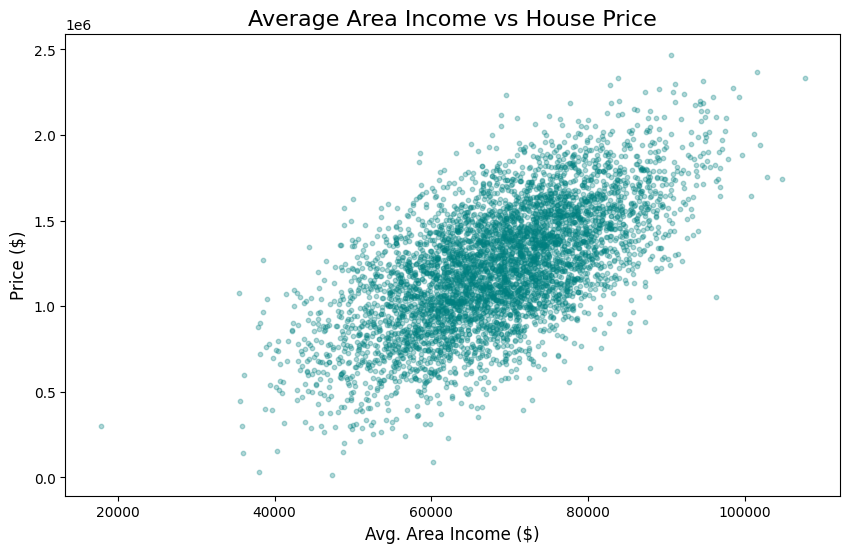

In [9]:
# CELL 9: Scatter plot — Avg. Area Income vs Price
plt.figure(figsize=(10, 6))

plt.scatter(df['Avg. Area Income'], df['Price'], alpha=0.3, color='teal', s=10)

plt.title('Average Area Income vs House Price', fontsize=16)
plt.xlabel('Avg. Area Income ($)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.show()

In [10]:
# CELL 10: Separate features and target variable
X = df[['Avg. Area Income', 'Avg. Area House Age',
        'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms',
        'Area Population']]

y = df['Price']

print(f"Features (X) shape: {X.shape}")  # (5000, 5) → 5000 samples, 5 features
print(f"Target (y) shape:   {y.shape}")    # (5000,) → 5000 price values

Features (X) shape: (5000, 5)
Target (y) shape:   (5000,)


In [11]:
# CELL 11: Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% of data goes to testing, 80% to training
    random_state=42    # Seed for reproducibility (same split every time)
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)")

Training set: 4000 samples (80%)
Testing set:  1000 samples (20%)


In [12]:
# CELL 12: Create and train the Linear Regression model
model = LinearRegression()

model.fit(X_train, y_train)
print("✅ Model trained successfully!")

✅ Model trained successfully!


In [14]:
# CELL 13: Examine what the model learned
print(f"Intercept (b0): {model.intercept_:,.2f}")
print("\nFeature Coefficients:")
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coeff_df.to_string(index=False))

print("\n--- INTERPRETATION ---")
print("Each coefficient means:")
print("'For every 1-unit INCREASE in this feature,")
print(" the price changes by THIS MANY DOLLARS,")
print(" while keeping ALL other features the same.'")
for i, row in coeff_df.iterrows():
    print(f"  • {row['Feature']}: ${row['Coefficient']:,.2f}")

Intercept (b0): -2,635,072.90

Feature Coefficients:
                     Feature   Coefficient
            Avg. Area Income     21.652206
         Avg. Area House Age 164666.480722
   Avg. Area Number of Rooms 119624.012232
Avg. Area Number of Bedrooms   2440.377611
             Area Population     15.270313

--- INTERPRETATION ---
Each coefficient means:
'For every 1-unit INCREASE in this feature,
 the price changes by THIS MANY DOLLARS,
 while keeping ALL other features the same.'
  • Avg. Area Income: $21.65
  • Avg. Area House Age: $164,666.48
  • Avg. Area Number of Rooms: $119,624.01
  • Avg. Area Number of Bedrooms: $2,440.38
  • Area Population: $15.27


In [15]:
# CELL 14: Predict prices on the test set
y_pred = model.predict(X_test)

# Compare first 10 actual vs predicted
comparison = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': y_pred[:10],
    'Difference': y_test.values[:10] - y_pred[:10]
})
print("First 10 Predictions vs Actual Prices:")
print(comparison.to_string(index=False))

First 10 Predictions vs Actual Prices:
 Actual Price  Predicted Price    Difference
 1.339096e+06     1.308588e+06  30508.150248
 1.251794e+06     1.237037e+06  14756.949343
 1.340095e+06     1.243429e+06  96665.625899
 1.431508e+06     1.228900e+06 202607.409824
 1.042374e+06     1.063321e+06 -20947.383012
 1.555321e+06     1.544058e+06  11262.449653
 1.250882e+06     1.094775e+06 156107.586827
 1.039381e+06     8.332847e+05 206095.999087
 8.324752e+05     7.884129e+05  44062.333228
 1.420648e+06     1.469715e+06 -49066.585287


In [16]:
# CELL 15: Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):       ${mae:,.2f}")
print(f"Mean Squared Error (MSE):        ${mse:,.2f}")
print(f"Root Mean Squared Error (RMSE):  ${rmse:,.2f}")
print(f"R-squared (R²) Score:            {r2:.4f}")
print(f"\n→ The model explains {r2*100:.2f}% of the variance in house prices.")

Mean Absolute Error (MAE):       $80,879.10
Mean Squared Error (MSE):        $10,089,009,300.89
Root Mean Squared Error (RMSE):  $100,444.06
R-squared (R²) Score:            0.9180

→ The model explains 91.80% of the variance in house prices.


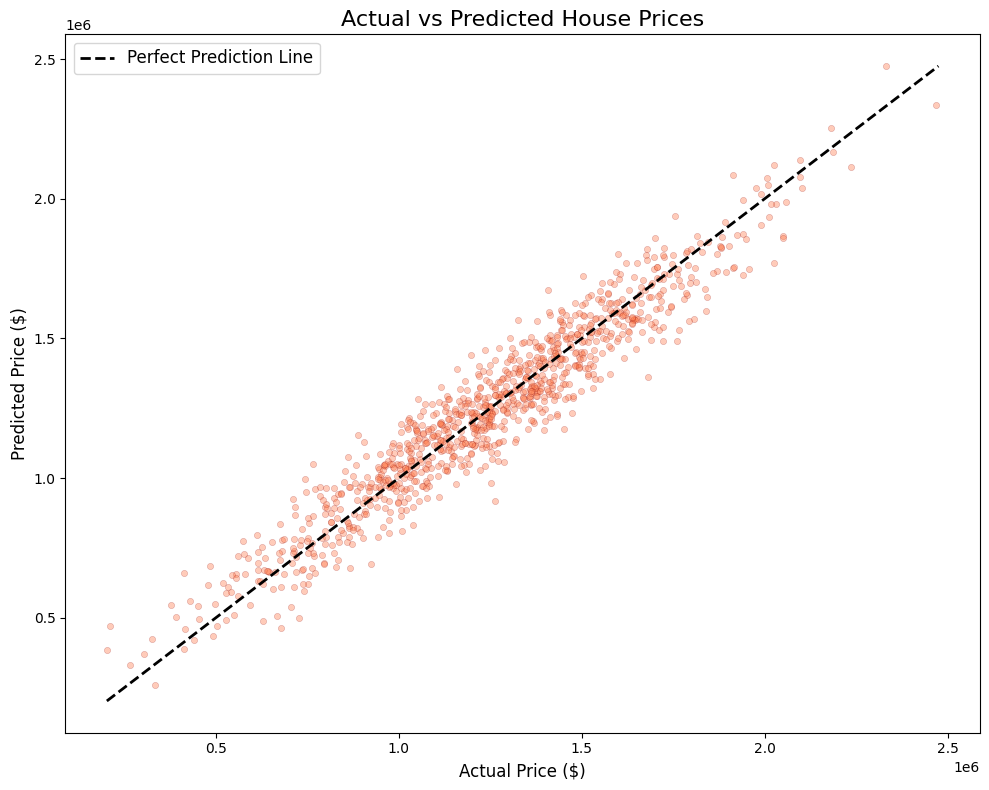

In [17]:
# CELL 16: Scatter plot of Actual vs Predicted prices
plt.figure(figsize=(10, 8))

plt.scatter(y_test, y_pred, alpha=0.4, color='coral', edgecolors='darkred',
            linewidths=0.3, s=20)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2,
         label='Perfect Prediction Line')

plt.title('Actual vs Predicted House Prices', fontsize=16)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

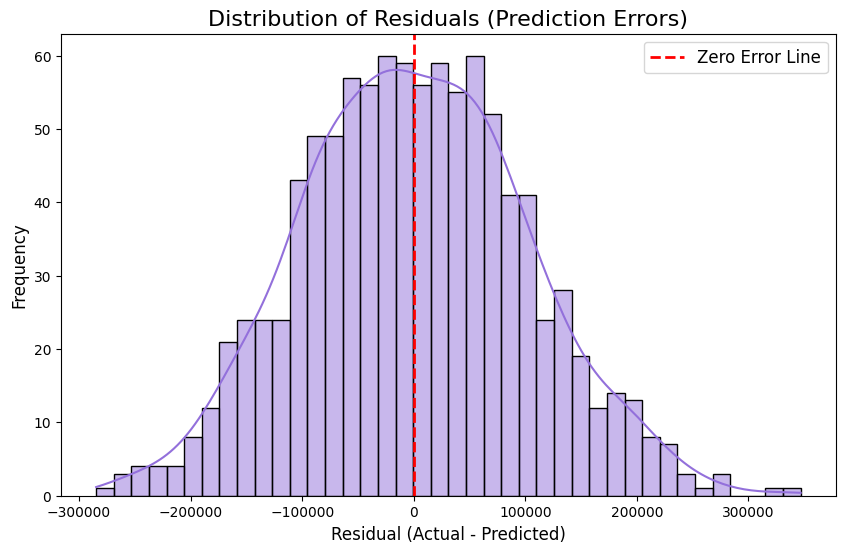

In [18]:
# CELL 17: Distribution of prediction errors (residuals)
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=40, color='mediumpurple')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

plt.title('Distribution of Residuals (Prediction Errors)', fontsize=16)
plt.xlabel('Residual (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)
plt.show()

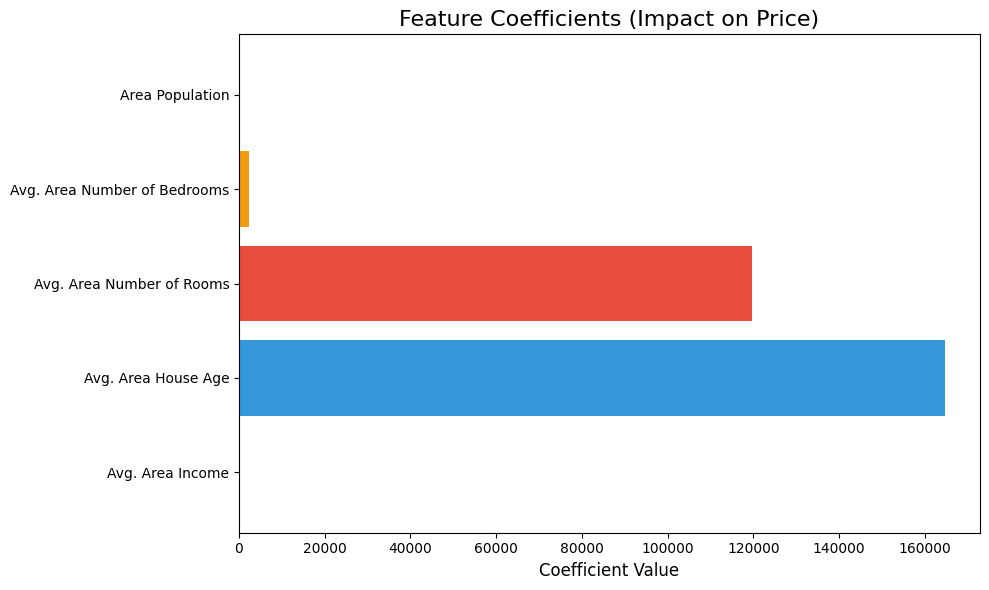

In [19]:
# CELL 18: Which features matter most? (Coefficient magnitudes)
plt.figure(figsize=(10, 6))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors)

plt.title('Feature Coefficients (Impact on Price)', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# CELL 19: Use the trained model to predict price for a brand new house
new_house = pd.DataFrame({
    'Avg. Area Income': [75000],
    'Avg. Area House Age': [7],
    'Avg. Area Number of Rooms': [8],
    'Avg. Area Number of Bedrooms': [4],
    'Area Population': [40000]
})

predicted_price = model.predict(new_house)

print("🏠 New House Details:")
print(f"   Income in Area:    $75,000")
print(f"   House Age:         7 years")
print(f"   Number of Rooms:   8")
print(f"   Number of Bedrooms: 4")
print(f"   Area Population:   40,000")
print(f"\n⭐ Predicted Selling Price: ${predicted_price[0]:,.2f}")

🏠 New House Details:
   Income in Area:    $75,000
   House Age:         7 years
   Number of Rooms:   8
   Number of Bedrooms: 4
   Area Population:   40,000

⭐ Predicted Selling Price: $1,719,074.04
